# Laboratório - Busca Adversarial e Minimax

## Ajustando ambiente

In [331]:
import random
import math
import matplotlib.pyplot as plt
import copy

## Motivação

Buscas adversariais contemplam métodos que permitem o estudo de ambientes onde **agentes possuem objetivos conflitantes**. Para pesquisadores de IA, a natureza simplificada dos jogos (como xadrez, Go e pôquer) é uma grande vantagem, pois o estado do jogo é fácil de representar e os agentes são restritos a um número pequeno de ações com efeitos definidos por regras precisas. Ao contrário do caos das escaramuças do mundo real, os jogos oferecem um laboratório controlado para modelar agentes que tentam ativamente derrotar uns aos outros.

Em cenários modernos, as técnicas de busca adversarial e a teoria dos jogos expandiram-se para além dos tabuleiros, sendo fundamentais na análise de **sistemas econômicos complexos**, como leilões de direitos de exploração e definição de preços competitivos. No campo da **segurança cibernética**, esses métodos são aplicados para detectar comportamentos anômalos e modelar a proliferação de malwares, combatendo inclusive ataques de *phishing* e extorsão automatizados. A **interação entre humanos e robôs** em ambientes dinâmicos, como a negociação de manobras de ultrapassagem entre um carro autônomo e motoristas humanos, também é formulada através desses princípios estratégicos. Além disso, a aplicação em jogos de vídeo de larga escala, como **StarCraft II**, exige que os agentes lidem com observabilidade parcial e decisões em tempo real, aproximando-se da complexidade do mundo real. Por fim, a busca adversarial fornece a base matemática para os **Jogos de Assistência**, cruciais para o problema do **alinhamento de valores**, onde um agente deve agir em benefício de um humano mesmo sob incerteza sobre os objetivos reais desse usuário.

### Métodos de Busca Adversarial

*   **Minimax:** Um algoritmo para encontrar a jogada ideal em jogos determinísticos de informação perfeita.
*   **Poda Alpha-Beta (Alpha–Beta Pruning):** Uma técnica que aumenta a eficiência da busca, ignorando partes da árvore que não influenciam a decisão final.
*   **Busca Heurística:** Utilizada quando não há tempo para explorar a árvore até o fim, aplicando uma **função de avaliação** para estimar quem está vencendo.
*   **Monte Carlo Tree Search (MCTS):** Uma estratégia que estima o valor de um estado através de médias de simulações (playouts) completas do jogo.
*   **Expectiminimax:** Uma generalização do Minimax para **jogos estocásticos** que incluem elementos de sorte, como dados.
*   **Abordagens para Informação Imperfeita:** Métodos que utilizam **estados de crença** para lidar com jogos onde nem todos os dados são visíveis para todos os jogadores (como pôquer ou Kriegspiel).

## Objetivos de aprendizagem

## Fundamentação Teórica

Na unidade anterior, trabalhamos com agentes **baseados em objetivos**.  Esse tipo de agente, simplesmente busca alcançar um estado que satisfaça uma condição de vitória ou meta, o que é análogo a problemas de planejamento onde o resultado desejado deve ser garantido independentemente das ações externas. A partir desse momento, iremos trabalhar com **agentes baseados em utilidade**. Agentes baseados em utilidade operam em ambientes competitivos onde existem múltiplos resultados possíveis com diferentes graus de "desejabilidade". Nesses casos, a IA não busca apenas "chegar ao fim", mas sim maximizar um valor numérico que representa seu desempenho. Dessa forma, o agente consegue distinguir entre uma vitória esmagadora, um empate ou uma derrota marginal, permitindo uma tomada de decisão mais refinada em jogos complexos.

### Minimax

Como ja mencionado, um dos motores de busca tradicionais de busca competitiva esta associado ao algoritmo chamado Minimax. No Minimax, a **função de utilidade** (payoff) é o componente que define o valor numérico final para um jogador quando o jogo atinge um **estado terminal**. Ela mapeia o resultado do jogo (vitória, derrota ou empate) em um número real, permitindo que o algoritmo compare diferentes caminhos na árvore de jogo.

A **árvore de jogo** uma representação estruturada de todas as possibilidades de jogadas em uma partida, sobreposta ao grafo do espaço de estados. Cada **nó** da árvore representa um "estado" ou posição específica do jogo (como a configuração atual de peças em um tabuleiro). As **arestas** (ou ramos) que conectam esses nós representam os movimentos legais que um jogador pode realizar para transformar um estado em outro. A árvore é organizada em níveis que representam os turnos. Para jogos complexos como o xadrez, essa árvore é vasta (com mais de $10^{40}$ nós), sendo considerada mais um construto teórico do que algo que possa ser totalmente realizado fisicamente

Em algoritmos de **busca adversarial**, como o **Minimax**, os jogos são definidos por **componentes formais** que caracterizam seu espaço de estados e mecânicas. Tradicionalmente, esses componentes são os seguintes:

*   **Estado Inicial ($S_0$):** Especifica como o jogo está configurado em seu início.
*   **TO-MOVE($s$):** Identifica o jogador cuja vez é de realizar um movimento no estado $s$.
*   **ACTIONS($s$):** Define o conjunto de **movimentos legais** ou ações que podem ser executadas em um determinado estado.
*   **RESULT($s, a$):** Representa o **modelo de transição**, que determina o novo estado resultante da aplicação da ação $a$ no estado $s$.
*   **IS-TERMINAL($s$):** O **teste terminal**, que retorna verdadeiro quando o jogo acabou e falso caso contrário.
*   **UTILITY($s, p$):** A **função de utilidade** (também conhecida como função de *payoff*), que define o **valor numérico final** para o jogador $p$ quando o jogo termina em um estado terminal.

A integração desses elementos permite a construção da árvore de jogo (ver abaixo). O algoritmo Minimax utiliza essa árvore para determinar a **decisão ótima**, assumindo que todos os agentes jogam de forma ideal para maximizar seus próprios resultados.

<details>
  <summary>O que seria uma decisão ótima para o Minimax?</summary>

Uma **decisão ótima** no algoritmo Minimax é a escolha de um movimento que garante a **máxima utilidade** para o jogador (MAX), partindo da premissa de que o oponente (MIN) também jogará de forma ideal para minimizar esse valor. Essa decisão é determinada pelo cálculo do **valor Minimax** de cada estado sucessor a partir do nó raiz, representando a utilidade de estar naquele estado assumindo que ambos os lados ajam perfeitamente até o fim do jogo. Formalmente, a decisão ótima é a ação que leva ao estado com o **maior valor Minimax possível**. O algoritmo assume um cenário de "pior caso" onde o adversário é implacável; se o oponente não jogar de forma ideal, o jogador MAX poderá obter um resultado ainda melhor do que o valor previsto pela decisão ótima, mas nunca pior.

</details>

### Árvore de jogo

Abaixo, observe uma partida a apenas **três movimentos do fim**. Através desta simulação prática, podemos visualizar conceitos fundamentais como a construção da árvore de jogo: a) a definição de **ply** (turnos de decisão de cada jogador); b) a aplicação da **função de utilidade** e; c) o processo de **retropropagação de valores**, que permite ao algoritmo identificar a jogada que garante o melhor resultado possível, assumindo que ambos os lados joguem de forma ideal.

A árvore de jogos é a estrutura fundamental na busca adversarial. Ela serve como o modelo teórico sobre o qual operam algoritmos essenciais: o **Minimax**, que explora essa árvore para determinar a decisão ótima através de uma busca em profundidade; a **Poda Alpha-Beta**, que otimiza esse processo ao descartar ramos da árvore que comprovadamente não afetam a escolha final; e o **Monte Carlo Tree Search (MCTS)**, que constrói e expande a árvore de forma seletiva por meio de simulações e cálculos de média de utilidade.

## Implementação

A partir desse momento, traduzimos a estrutura lógica do jogo para ferramentas de manipulação de dados. Aqui construímos as funções utilitárias que permitem ao algoritmo "enxergar" o tabuleiro e "experimentar" movimentos. O roteiro seguirá estas etapas fundamentais: a) Modelo de Transição: Implementação das funções ACTIONS e RESULT para listar jogadas legais e gerar novos estados no tabuleiro; b) Avaliação de Resultados: Construção do teste terminal (IS-TERMINAL) e da função de utilidade (UTILITY) para identificar e pontuar o fim da partida; c) Busca e Decisão: Execução do algoritmo Minimax para explorar a árvore de jogo e retropropagar os valores das folhas até a raiz, definindo a estratégia ótima.



### Instanciando ambiente do agente

In [332]:
def create_board():
    """Cria e retorna um tabuleiro de Tic-tac-toe 3x3 vazio."""
    return [[None for col_idx in range(3)] for row_idx in range(3)]

In [333]:
board_example = create_board()
for row in board_example:
    print(row)

[None, None, None]
[None, None, None]
[None, None, None]


### Função para visualizar o tabuleiro do Jogo da Velha

In [334]:
def draw_board(board, title="Tabuleiro"):
    """
    Gera uma imagem do tabuleiro usando matplotlib.
    """
    figure, axis = plt.subplots(figsize=(4, 4))

    axis.set_xlim(0, 3)
    axis.set_ylim(0, 3)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(title)

    # Desenha as linhas do tabuleiro
    for position in range(1, 3):
        axis.plot([position, position], [0, 3], linewidth=2, color="black")
        axis.plot([0, 3], [position, position], linewidth=2, color="black")

    # Desenha X e O nas casas ocupadas
    for row_idx in range(len(board)):
        for col_idx in range(len(board[row_idx])):
            cell = board[row_idx][col_idx]

            if cell is not None:
                x_position = col_idx + 0.5
                y_position = 2.5 - row_idx

                axis.text(
                    x_position,
                    y_position,
                    cell,
                    fontsize=40,
                    ha="center",
                    va="center"
                )

    plt.show()

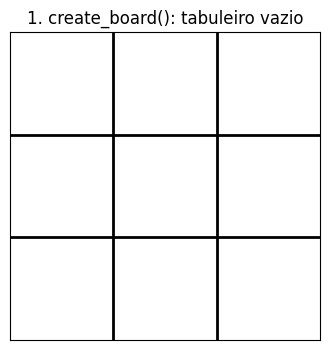

In [335]:
draw_board(board_example, title="1. create_board(): tabuleiro vazio")

### Função para ações validadas e movimentações

Abaixo, implementamos a mecânica de exploração do tabuleiro através de dois componentes fundamentais: o mapeamento de ACTIONS(s) e o modelo de transição RESULT(s, a).

In [336]:
def get_available_actions(board):
    """
    Retorna todas as posições vazias do tabuleiro.
    Cada ação é representada como uma tupla: (linha, coluna)

    Esta função corresponde à ideia de ACTIONS(s).
    """
    available_actions = []

    for row_idx in range(len(board)):
        for col_idx in range(len(board[row_idx])):
            if board[row_idx][col_idx] is None:
                action = (row_idx, col_idx)
                available_actions.append(action)

    return available_actions


In [337]:
def apply_move(board, action, player):
    """
    Aplica uma jogada no tabuleiro.
    Esta função corresponde à ideia de RESULT(s, a)
    """
    board[action[0]][action[1]] = player

In [338]:
def undo_move(board, action, player = None):
    """
    Desfaz uma jogada previamente aplicada.
    Isso permite testar vários ramos da árvore de jogo usando o mesmo tabuleiro.
    """
    board[action[0]][action[1]] = player

#### Demonstração

In [339]:
player, action = "X", (1, 1)
apply_move(board_example, action, player)

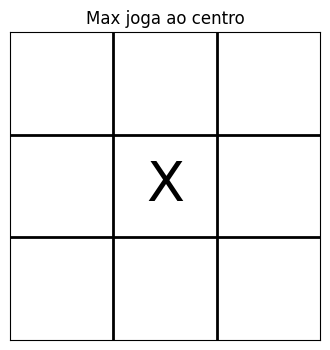

In [340]:
draw_board(board_example, title="Max joga ao centro")

In [341]:
player, action = None, (1, 1)
undo_move(board_example, action)

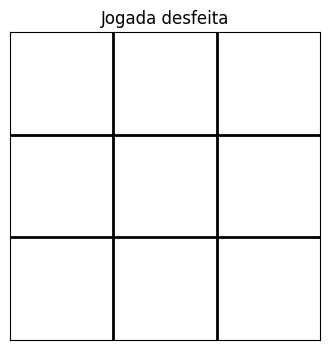

In [342]:
draw_board(board_example, title="Jogada desfeita")

In [343]:
available_actions = get_available_actions(board_example)
print(f"Ações disponíveis: {available_actions}")

Ações disponíveis: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]


### Função de utilidade e verificação de termino

A seguir, iremos implementar os componentes exigidos para representação de um algoritmo de busca adversarial, focando obviamente na estrutura do Minimax. Aqui, implementamos os componentes `IS-TERMINAL` e logo em seguida traduzimos a identidade do jogador no valor de `UTILITY`.

In [344]:
def utility(board):
    """
    Converte o nome do jogador ('X' ou 'O') para seu valor de utilidade padrão.
    'X' representa o jogador MAX (+1).
    'O' representa o jogador MIN (-1).
    """

    winner = check_winner(board)

    if winner == "X":
        return 1
    if winner == "O":
        return -1
    return 0


In [345]:
def check_winner(board):
    """
    Verifica se há vencedor, empate ou tabuleiro vazio.

    Corresponde aos componentes IS-TERMINAL(s).
    """
    # Verifica se o tabuleiro está completamente vazio usando uma abordagem linear
    # Achata a lista de listas para uma única lista e verifica se todos os elementos são 'None'
    flattened_board = [cell for row in board for cell in row]
    if all(cell == None for cell in flattened_board):
        return 'Inicial'

    # Linhas
    for row_idx in range(len(board)):
        if board[row_idx][0] == board[row_idx][1] == board[row_idx][2] and board[row_idx][0] is not None:
            return board[row_idx][0]

    # Colunas
    for col_idx in range(len(board[0])):
        if board[0][col_idx] == board[1][col_idx] == board[2][col_idx] and board[0][col_idx] is not None:
            return board[0][col_idx]

    # Verifica diagonais
    if board[0][0] == board[1][1] == board[2][2] and board[0][0] is not None:
        return board[0][0]
    if board[0][2] == board[1][1] == board[2][0] and board[0][2] is not None:
        return board[0][2]

    # Verifica empate (se não há mais movimentos e ninguém venceu)
    # Usando a estratégia de 'achatar' a estrutura para verificar células vazias
    if None not in flattened_board:
        return 'Empate'

    return None # Ninguém venceu e não é empate ainda

#### Demonstração

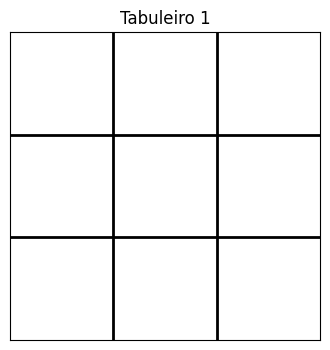


Vencedor obtido: Inicial


In [368]:
# Tabuleiro vazio (sem vencedor)
board1 = [
    [None, None, None],
    [None, None, None],
    [None, None, None]
]

winner1 = check_winner(board1)
draw_board(board1, title="Tabuleiro 1")

print(f"\nVencedor obtido: {winner1}")

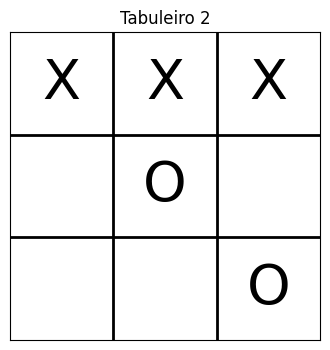

Vencedor obtido: X


In [367]:
# Vencedor na primeira linha (X)
board2 = [
    ['X', 'X', 'X'],
    [None, 'O', None],
    [None, None, 'O']
]

winner2 = check_winner(board2)
draw_board(board2, title="Tabuleiro 2")

print(f"Vencedor obtido: {winner2}")

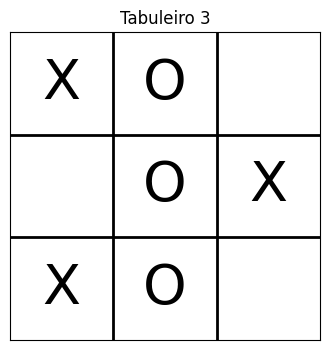

Vencedor obtido: O


In [366]:
# Vencedor na segunda coluna (O)
board3 = [
    ['X', 'O', None],
    [None, 'O', 'X'],
    ['X', 'O', None]
]

winner3 = check_winner(board3)
draw_board(board3, title="Tabuleiro 3")

print(f"Vencedor obtido: {winner3}")

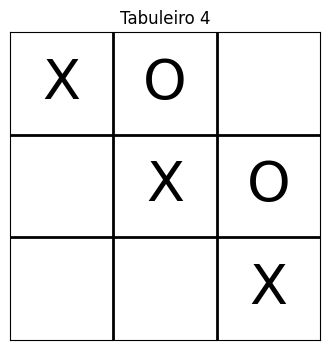

Vencedor obtido: X


In [369]:
# Vencedor na diagonal principal (X)
board4 = [
    ['X', 'O', None],
    [None, 'X', 'O'],
    [None, None, 'X']
]

winner4 = check_winner(board4)
draw_board(board4, title="Tabuleiro 4")

print(f"Vencedor obtido: {winner4}")

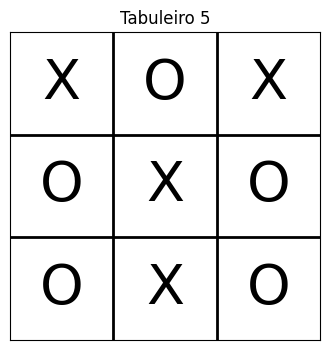

Vencedor obtido: Empate


In [364]:
# Empate (sem vencedor)
board5 = [
    ['X', 'O', 'X'],
    ['O', 'X', 'O'],
    ['O', 'X', 'O']
]

winner6 = check_winner(board5)
draw_board(board5, title="Tabuleiro 5")

print(f"Vencedor obtido: {winner6}")

### Minimax


O algoritmo Minimax opera através de uma **busca recursiva** que simula o pensamento estratégico: "se eu jogar aqui, qual será a melhor resposta do meu oponente?". As funções `max_value` e `min_value` implementam essa alternância de interesses, onde o algoritmo desce até os estados terminais para coletar a utilidade e, em seguida, propaga esses valores de volta para cima. Esse processo de **retropropagação** garante que o valor atribuído a cada movimento na raiz da árvore considere que ambos os jogadores farão as melhores escolhas possíveis em cada turno.

#### Função do MAX

In [351]:
def max_value(board):
    """
    Representa o turno de MAX, isto é, o jogador X.

    MAX quer escolher a ação que produz o maior valor possível.
    Por isso, inicializamos best_value com -infinito e usamos max().
    """
    if check_winner(board) is not None:
        return utility(board)

    best_value = -math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "X")
        value = min_value(board)
        undo_move(board, action)

        best_value = max(best_value, value)

    return best_value

#### Função do MIN

In [352]:
def min_value(board):
    """
    Representa o turno de MIN, isto é, o jogador O.

    MIN quer escolher a ação que produz o menor valor possível para MAX.
    Por isso, inicializamos best_value com +infinito e usamos min().
    """
    if check_winner(board) is not None:
        return utility(board)

    best_value = math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "O")
        value = max_value(board)
        undo_move(board, action)

        best_value = min(best_value, value)

    return best_value

### Função da heurística de decisão


Diferente das funções recursivas que calculam o valor de estados futuros, a `get_best_move` é o ponto de decisão final do agente no nó raiz. Ela funciona como um coordenador que avalia todas as jogadas legais disponíveis no momento e, baseando-se nos resultados retornados pelo motor Minimax, seleciona a **ação concreta** que maximiza a utilidade para o jogador. É nesta etapa que o planejamento teórico se transforma em uma jogada real executada no tabuleiro.

In [353]:
def get_best_move(board, player):
    """
    Retorna a melhor jogada para o jogador atual.
    """

    if player == "X":  # MAX
        best_value = -math.inf
        best_move = (-1, -1)

        for action in get_available_actions(board):
            apply_move(board, action, "X")
            move_value = min_value(board)
            undo_move(board, action)

            if move_value > best_value:
                best_value = move_value
                best_move = action

        return best_move

    if player == "O":  # MIN
        best_value = math.inf
        best_move = (-1, -1)

        for action in get_available_actions(board):
            apply_move(board, action, "O")
            move_value = max_value(board)
            undo_move(board, action)

            if move_value < best_value:
                best_value = move_value
                best_move = action

        return best_move


#### Demonstração

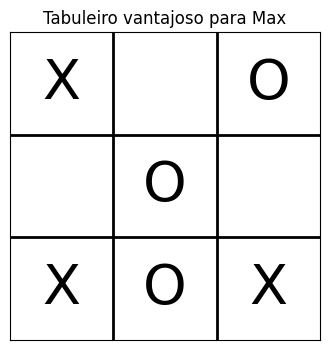

In [354]:
board_max_to_win = [
    ["X", None, "O"],
    [None, "O", None],
    ["X", "O", "X"]
]

draw_board(board_max_to_win, title="Tabuleiro vantajoso para Max")

In [355]:
available_actions = get_available_actions(board_max_to_win)
print(available_actions)

[(0, 1), (1, 0), (1, 2)]



Ação testada por X (MAX): (0, 1)


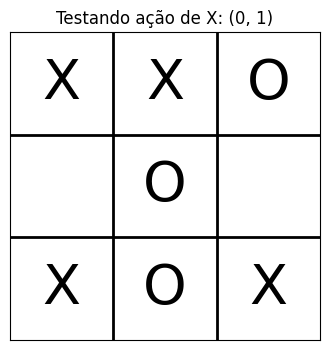

Vencedor após a ação: None
Valor Minimax da ação: 0

Ação testada por X (MAX): (1, 0)


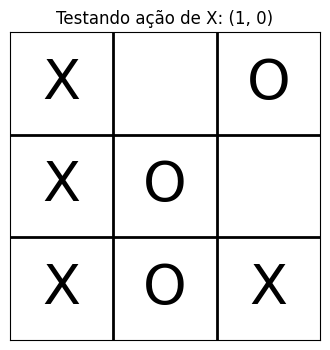

Vencedor após a ação: X
Valor Minimax da ação: 1

Ação testada por X (MAX): (1, 2)


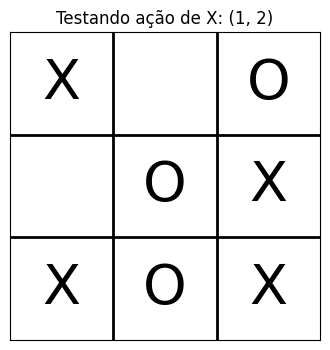

Vencedor após a ação: None
Valor Minimax da ação: -1


In [356]:
for action in available_actions:
    print(f"\nAção testada por X (MAX): {action}")

    apply_move(board_max_to_win, action, "X")

    winner_after_move = check_winner(board_max_to_win)
    action_value = min_value(board_max_to_win)

    draw_board(board_max_to_win, title=f"Testando ação de X: {action}")

    print(f"Vencedor após a ação: {winner_after_move}")
    print(f"Valor Minimax da ação: {action_value}")

    undo_move(board_max_to_win, action)

In [357]:
best_move_for_max = get_best_move(board_max_to_win, "X")
apply_move(board_max_to_win, best_move_for_max, "X")

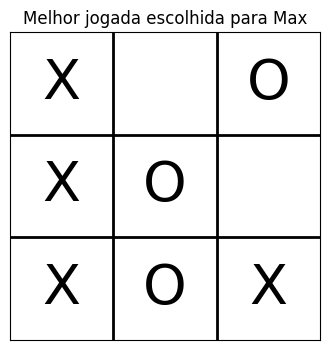

In [358]:
draw_board(board_max_to_win, title="Melhor jogada escolhida para Max")

In [359]:
utility_value = utility(board_max_to_win)
print(f"Utilidade do estado: {utility_value}")
print("Interpretação: +1 significa vitória de X (MAX).")

Utilidade do estado: 1
Interpretação: +1 significa vitória de X (MAX).


### Função para simular partida


Nesta etapa final, integramos todos os componentes desenvolvidos para observar o agente em ação. A função de simulação coordena a alternância de turnos (**TO-MOVE**) e aplica a decisão ótima calculada pelo motor de busca em cada estado. Aqui, validamos se o comportamento baseado em utilidade resulta na estratégia imbatível esperada, permitindo acompanhar o fluxo completo da partida — do estado inicial até o teste terminal (**IS-TERMINAL**) — e verificar se a IA consegue antecipar as jogadas do oponente para garantir o melhor desfecho possível.

In [371]:
def play_game(current_board = create_board(), current_player = "X", use_visualization=False):
    """
    Simula uma partida completa entre dois jogadores ótimos.

    X usa a lógica de MAX.
    O usa a lógica de MIN.

    A visualização é exibida depois de cada jogada.
    Dessa forma, o título do gráfico indica quem acabou de jogar.
    """

    board = current_board
    PLAYER_LABELS = {
    "X": "X (MAX)",
    "O": "O (MIN)"
    }

    print("Iniciando partida Minimax vs Minimax (X = MAX, O = MIN):")

    if use_visualization:
        draw_board(board, title="Estado inicial")

    while True:
        player_label = PLAYER_LABELS[current_player]
        print(f"Turno de: {player_label}")

        move = get_best_move(board, current_player)
        apply_move(board, move, current_player)

        if use_visualization:
            draw_board(board, title=f"Jogada de: {player_label}")

        winner = check_winner(board)
        if winner is not None:
            if winner == "X":
                print("Fim de jogo: X (MAX) venceu")
            elif winner == "O":
                print("Fim de jogo: O (MIN) venceu")
            else:
                print("Fim de jogo: Empate")
            break

        if current_player == "X":
            current_player = "O"
        else:
            current_player = "X"


## Exemplo prático

### Cenário 1

No **Cenário 1**, aplicamos tudo o que foi construído em uma simulação prática de partida completa. O objetivo é observar o comportamento dos agentes em tempo real, visualizando como a IA decide cada movimento a partir de um estado específico. Este cenário permite testar a eficácia da árvore de jogo e verificar se o algoritmo consegue garantir resultados ótimos (como o empate forçado no Jogo da Velha), demonstrando a transição de um agente baseado em objetivos para um **agente baseado em utilidade**.

Iniciando partida Minimax vs Minimax (X = MAX, O = MIN):


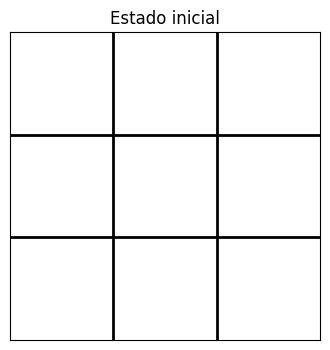

Turno de: X (MAX)


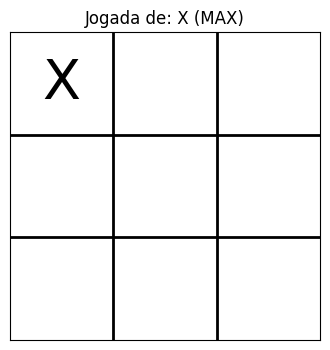

Turno de: O (MIN)


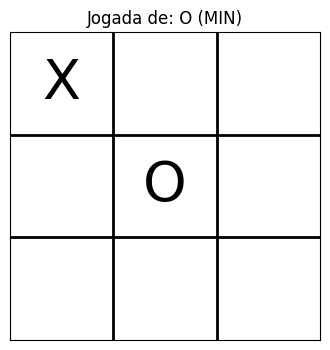

Turno de: X (MAX)


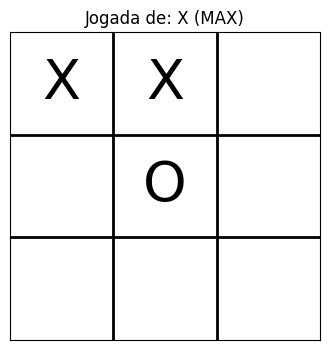

Turno de: O (MIN)


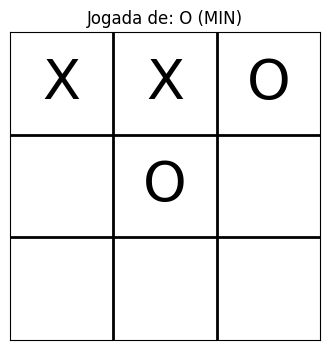

Turno de: X (MAX)


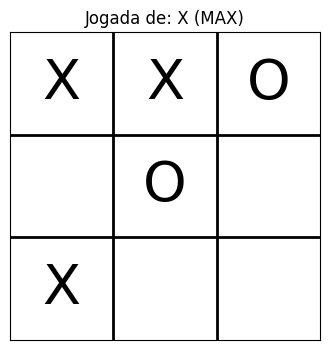

Turno de: O (MIN)


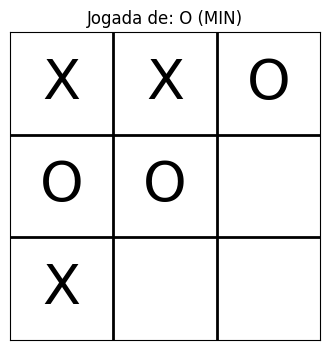

Turno de: X (MAX)


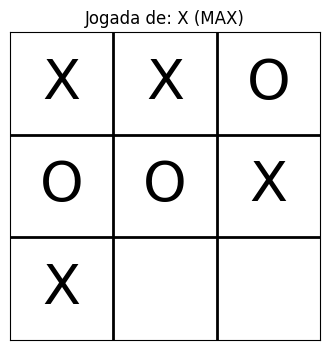

Turno de: O (MIN)


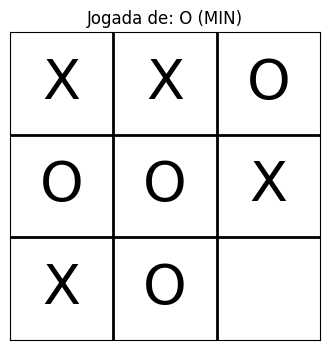

Turno de: X (MAX)


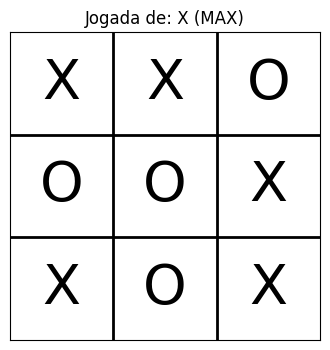

Fim de jogo: Empate


In [372]:
play_game(use_visualization=True)

### Cenário 2

### Cenário 3

## Key Takeaways

## Referências

1. Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern Approach. Prentice Hall.
2. https://www.geeksforgeeks.org/dsa/finding-optimal-move-in-tic-tac-toe-using-minimax-algorithm-in-game-theory/
